In [1]:
import html
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from matplotlib import style
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split

style.use('ggplot')

SEED = 42

# Chỉ dùng khi vẽ WordCloud/thống kê từ,
# không xóa khỏi dữ liệu đưa vào model.
eda_stop_words = set(STOPWORDS) - {
    'not', 'no', 'nor', 'never'
}


Đọc dữ liệu từ csv

In [2]:
df = pd.read_csv('../../dataset/IMDB Dataset.csv')
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

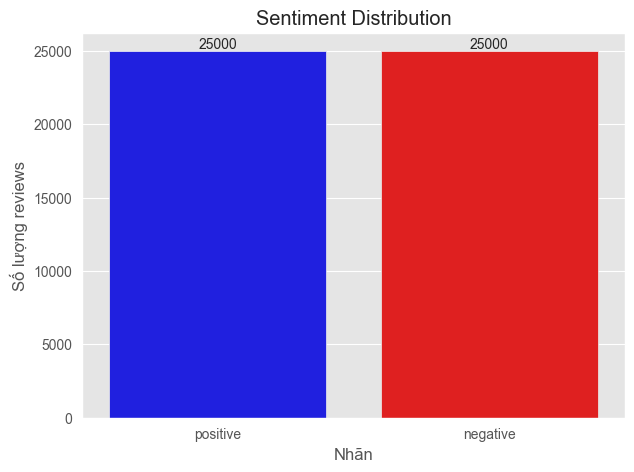

In [4]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x='sentiment',
    data=df,
    hue='sentiment',
    palette={
        'positive': 'blue',
        'negative': 'red'
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Sentiment Distribution")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng reviews")
plt.show()

In [5]:
for i in range(min(5, len(df))):
    print(f"Review #{i + 1}:")
    print(df['review'].iloc[i], "\n")
    print("Sentiment:", df['sentiment'].iloc[i], "\n")

Review #1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [6]:
#Hàm đếm từ
def no_of_words(text):
    return len(str(text).split())



In [7]:
df['word count'] = df['review'].apply(no_of_words)

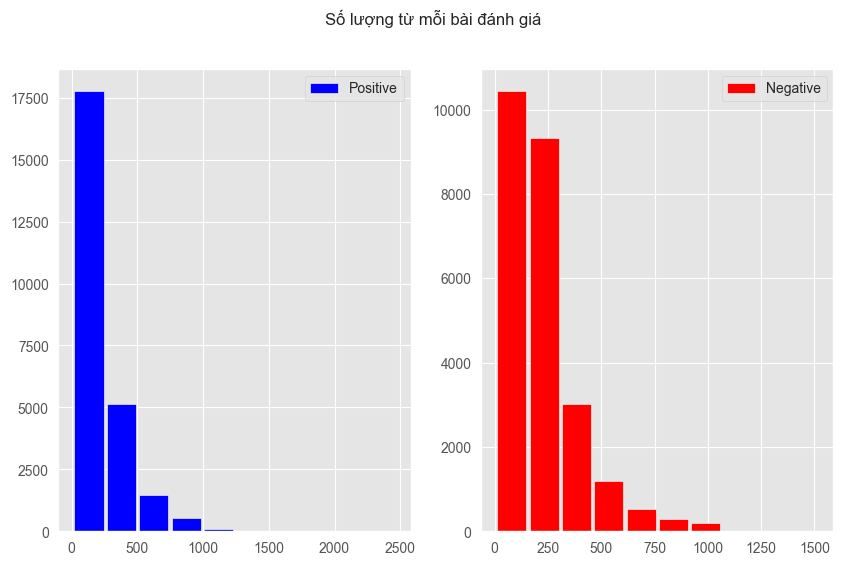

In [8]:
#Sự phân bố bài đánh giá

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word count'], label='Positive', color="blue", rwidth=0.9 );
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['word count'], label='Negative', color="red", rwidth=0.9 );
ax[1].legend(loc='upper right');

fig.suptitle("Số lượng từ mỗi bài đánh giá")
plt.show()

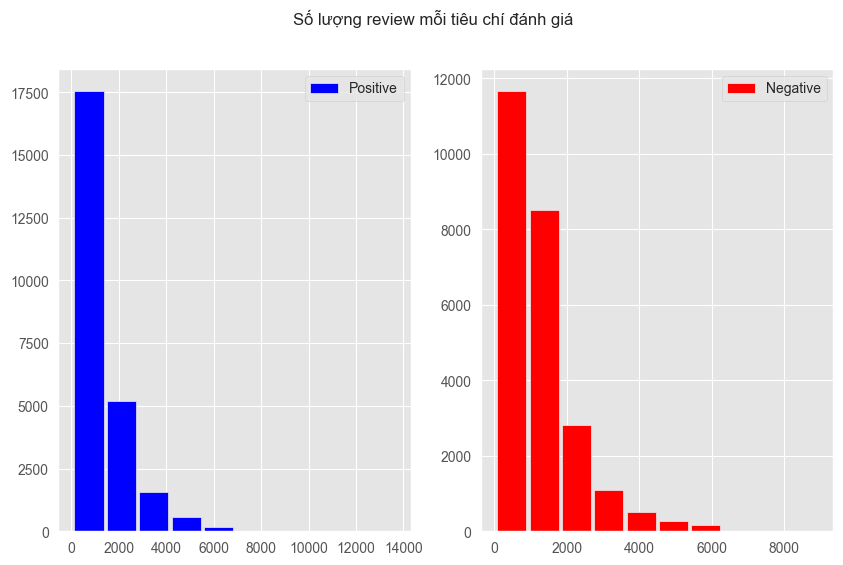

In [9]:
fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['review'].str.len(), label='Positive', color='blue', rwidth=0.9);
ax[0].legend(loc='upper right');
ax[1].hist(df[df['sentiment'] == 'negative']['review'].str.len(), label='Negative', color='red', rwidth=0.9);
ax[1].legend(loc='upper right');

fig.suptitle("Số lượng review mỗi tiêu chí đánh giá")
plt.show()

In [10]:
#Chuyển nhãn thành số
df = df.dropna(subset=['review', 'sentiment']).copy()

df['sentiment'] = (
    df['sentiment']
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df[df['sentiment'].isin(['positive', 'negative'])].copy()

df['label'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
}).astype('int32')

In [11]:
df.head()

,review,sentiment,word count,label
0,One of the other reviewers has mentioned that ...,positive,307,1
1,A wonderful little production. <br /><br />The...,positive,162,1
2,I thought this was a wonderful way to spend ti...,positive,166,1
3,Basically there's a family where a little boy ...,negative,138,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1


In [12]:
import nltk
nltk.download('punkt_tab')
#Xử lý các review
def data_processing(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Xóa các biến thể của <br>
    text = re.sub(r'<br\s*/?>', '', text)

    # Xóa HTML tag còn lại
    text = re.sub(r'<[^>]+>', '', text)

    # Xóa URL
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ', text
    )

    # Giữ chữ, số, khoảng trắng và dấu nháy đơn
    text = re.sub( r"[^a-z0-9\s']",' ',text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    return text




[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
df['clean_review'] = df['review'].apply(
    data_processing
)

df = df[df['clean_review'].str.len() > 0 ].copy()

df[['review', 'clean_review', 'sentiment', 'label']].head()

,review,clean_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love in the time of money is a...,positive,1


In [14]:
#Các bài bị trùng
duplicated_count = df.duplicated().sum()
print("số lượng bài đánh giá bị trùng: ", duplicated_count)

số lượng bài đánh giá bị trùng:  418


In [15]:
df['word_count'] = df['clean_review'].apply(no_of_words)

df['character_count'] = df['clean_review'].str.len()

df.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
0,One of the other reviewers has mentioned that ...,positive,307,1,one of the other reviewers has mentioned that ...,308,1678
1,A wonderful little production. <br /><br />The...,positive,162,1,a wonderful little production the filming tech...,158,943
2,I thought this was a wonderful way to spend ti...,positive,166,1,i thought this was a wonderful way to spend ti...,165,880
3,Basically there's a family where a little boy ...,negative,138,0,basically there's a family where a little boy ...,132,691
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1,petter mattei's love in the time of money is a...,225,1243


In [16]:
pos_reviews = df[df['label'] ==1] #chọn ra các positive review
pos_reviews.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
0,One of the other reviewers has mentioned that ...,positive,307,1,one of the other reviewers has mentioned that ...,308,1678
1,A wonderful little production. <br /><br />The...,positive,162,1,a wonderful little production the filming tech...,158,943
2,I thought this was a wonderful way to spend ti...,positive,166,1,i thought this was a wonderful way to spend ti...,165,880
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,1,petter mattei's love in the time of money is a...,225,1243
5,"Probably my all-time favorite movie, a story o...",positive,119,1,probably my all time favorite movie a story of...,121,635


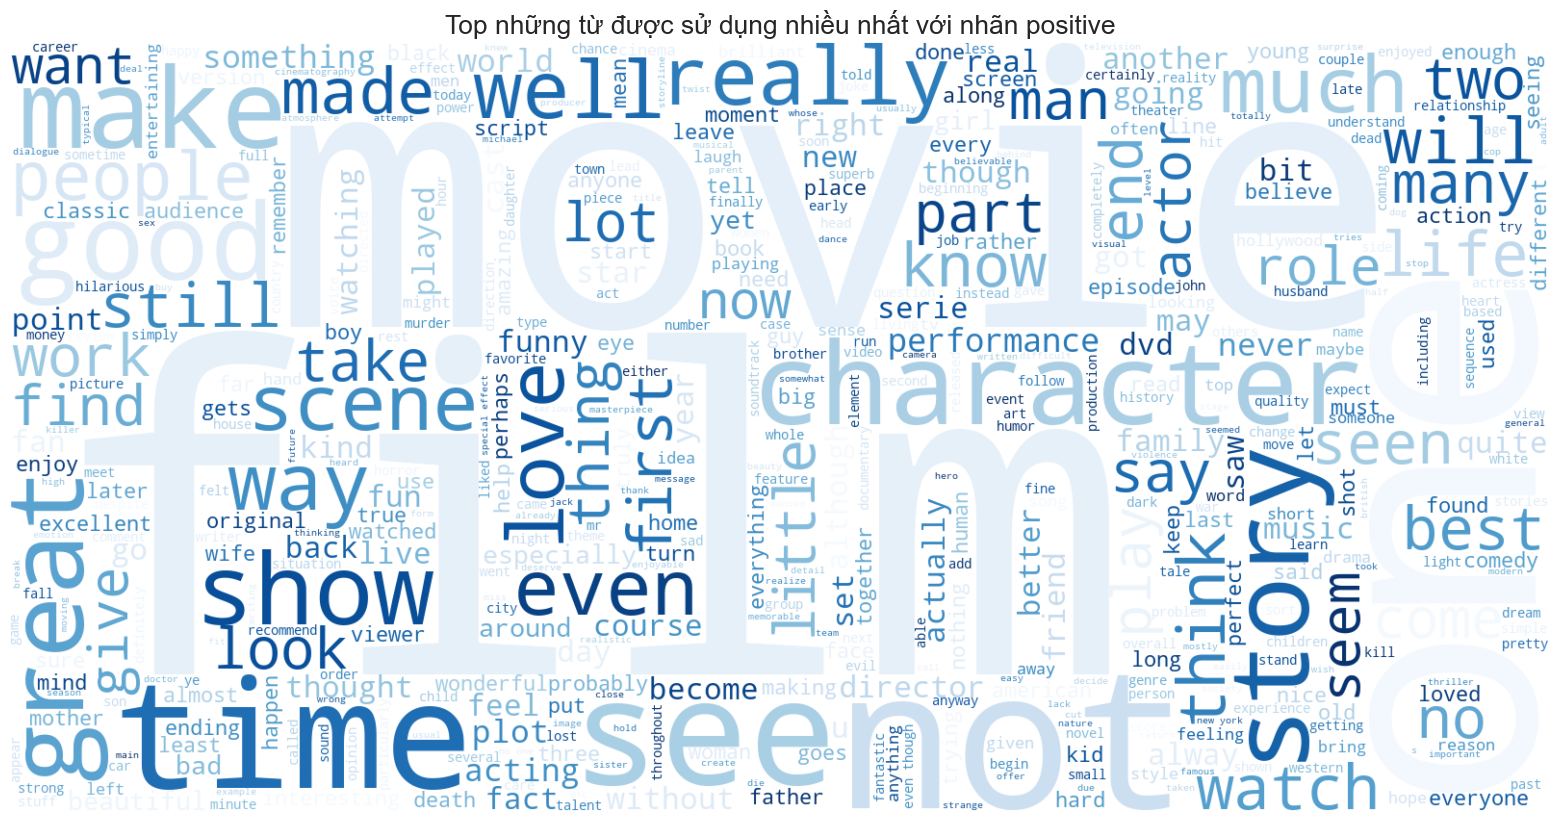

In [17]:
positive_sample = pos_reviews[
    'clean_review'
].sample(
    n=min(5000, len(pos_reviews)),
    random_state=SEED
)

text = ' '.join(positive_sample)

plt.figure(
    figsize=(20, 10),
    facecolor='white'
)

wordcloud = WordCloud(
    max_words=500,
    width=1600,
    height=800,
    background_color='white',
    stopwords=eda_stop_words,
    colormap='Blues',
    random_state=SEED
).generate(text)

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(
    'Top những từ được sử dụng nhiều nhất với nhãn positive',
    fontsize=19
)

plt.show()

In [18]:
#đếm ra các từ thường được sử dụng
positive_count = Counter()

for review_text in pos_reviews['clean_review'].values:
    for word in review_text.split():
        if word not in eda_stop_words:
            positive_count[word] += 1

positive_count.most_common(15)


[('film', 40989),
 ('movie', 37447),
 ('not', 28282),
 ('one', 26999),
 ('good', 14981),
 ('great', 12947),
 ('story', 12833),
 ('well', 12720),
 ('time', 12711),
 ('see', 12243),
 ('really', 10732),
 ('will', 10261),
 ('even', 9611),
 ('first', 9219),
 ('no', 9214)]

In [19]:
pos_words = pd.DataFrame(positive_count.most_common(15))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,40989
1,movie,37447
2,not,28282
3,one,26999
4,good,14981


In [20]:
px.bar(pos_words, x='count', y='word', title='', color='word')

In [21]:
from operator import neg
#các nhãn negative
neg_reviews = df[df['label'] == 0]
neg_reviews.head()

,review,sentiment,word count,label,clean_review,word_count,character_count
3,Basically there's a family where a little boy ...,negative,138,0,basically there's a family where a little boy ...,132,691
7,"This show was an amazing, fresh & innovative i...",negative,174,0,this show was an amazing fresh innovative idea...,173,902
8,Encouraged by the positive comments about this...,negative,130,0,encouraged by the positive comments about this...,126,647
10,Phil the Alien is one of those quirky films wh...,negative,96,0,phil the alien is one of those quirky films wh...,92,524
11,I saw this movie when I was about 12 when it c...,negative,180,0,i saw this movie when i was about 12 when it c...,179,897


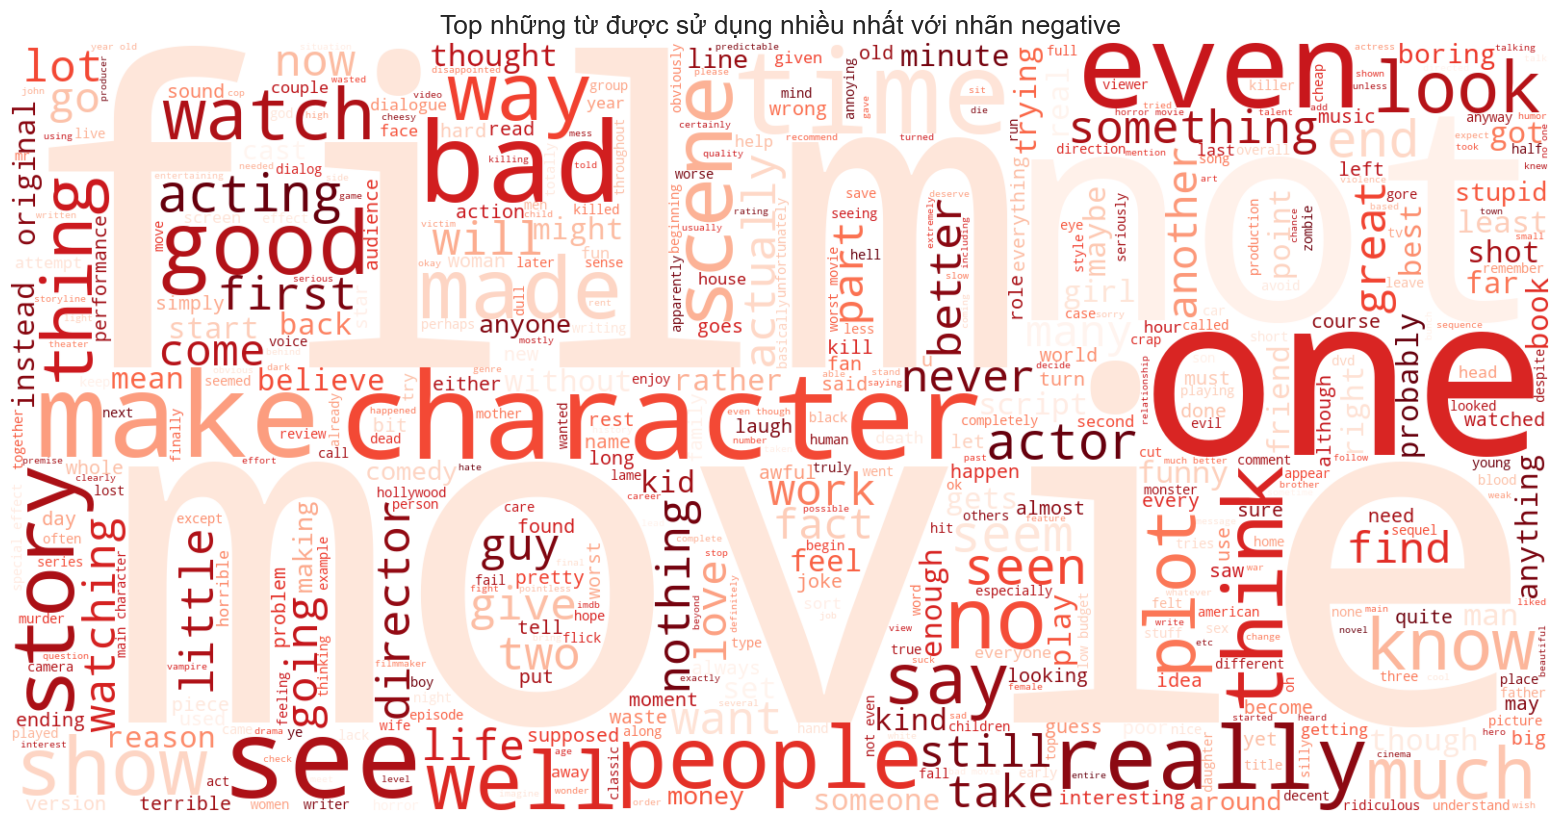

In [22]:
negative_sample = neg_reviews[
    'clean_review'
].sample(
    n=min(5000, len(neg_reviews)),
    random_state=SEED
)

text = ' '.join(negative_sample)

plt.figure(
    figsize=(20, 10),
    facecolor='white'
)

wordcloud = WordCloud(
    max_words=500,
    width=1600,
    height=800,
    background_color='white',
    stopwords=eda_stop_words,
    colormap='Reds',
    random_state=SEED
).generate(text)

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(
    'Top những từ được sử dụng nhiều nhất với nhãn negative',
    fontsize=19
)

plt.show()

In [23]:
negative_count = Counter()

for review_text in neg_reviews[
    'clean_review'
].values:
    for word in review_text.split():
        if word not in eda_stop_words:
            negative_count[word] += 1

negative_count.most_common(15)
neg_words = pd.DataFrame(negative_count.most_common(15))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movie,49582
1,film,36677
2,not,32421
3,one,26029
4,no,16040


In [24]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color='word')

In [25]:
#Chia tập dữ liệu
X = df['clean_review'].copy()
y = df['label'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000,)
y shape: (50000,)


In [26]:
#Lấy 70% train
x_train, x_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

In [27]:
#Chia x_temp thành 15% validation và 15% test:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


x_train = x_train.reset_index(drop=True)
x_val = x_val.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [28]:
print(
    "Size of x_train:",
    x_train.shape
)

print("Size of y_train:",y_train.shape)

print("Size of x_val:", x_val.shape)

print("Size of y_val:",y_val.shape)

print("Size of x_test:",x_test.shape)

print("Size of y_test:", y_test.shape)

assert len(x_train) == len(y_train)
assert len(x_val) == len(y_val)
assert len(x_test) == len(y_test)

Size of x_train: (35000,)
Size of y_train: (35000,)
Size of x_val: (7500,)
Size of y_val: (7500,)
Size of x_test: (7500,)
Size of y_test: (7500,)


**XUẤT DỮ LIỆU ĐÃ LÀM**

In [29]:
train_df = pd.DataFrame({'clean_review': x_train,'label': y_train})

validation_df = pd.DataFrame({'clean_review': x_val,'label': y_val})

test_df = pd.DataFrame({'clean_review': x_test,'label': y_test})

In [30]:
train_df.to_csv('train.csv', index=False)

validation_df.to_csv('validation.csv',index=False)

test_df.to_csv('test.csv',index=False)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (35000, 2)
Validation: (7500, 2)
Test: (7500, 2)


# Kết thúc phần làm sạch dữ liệu và chia dữ liệu

```
"This movie is really good"
        ↓
Tokenizer của DistilBERT
        ↓
input_ids + attention_mask
        ↓
DistilBERT
        ↓
Classification Head
        ↓
0 hoặc 1
        ↓
Negative / Positive
```

## 1. Import thư viện

In [43]:
import numpy as np
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support)

## 2. Check data

In [44]:
print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain:")
display(train_df.head())

print("\nLabel distribution:")
print(train_df['label'].value_counts())

Train shape: (35000, 2)
Validation shape: (7500, 2)
Test shape: (7500, 2)

Train:


,clean_review,label
0,if you want to see a true thriller rent this i...,1
1,this is one of the first and best columbos sta...,1
2,this was the one movie to see about the civi w...,1
3,probably new zealands worst movie ever madethe...,0
4,i remember seeing this in the early 90's on uk...,1



Label distribution:
label
1    17500
0    17500
Name: count, dtype: int64


## 3. Convert từ pandas sang huggingface

### Lý do chuyển đổi
- Tối ưu bộ nhớ
- Tương thích với PyTorch / TensorFlow
<small>_Cấu trúc Dataset của Hugging Face được thiết kế riêng để tự động chuyển đổi dữ liệu thành các Tensor (torch.Tensor hoặc tf.Tensor)_</small>


In [45]:
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)

validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)

test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['clean_review', 'label'],
    num_rows: 35000
})
Dataset({
    features: ['clean_review', 'label'],
    num_rows: 7500
})
Dataset({
    features: ['clean_review', 'label'],
    num_rows: 7500
})


## 4. Chọn model

In [46]:
MODEL_NAME = "distilbert-base-uncased"

# 5. Tạo tokenizer

In [47]:
from dotenv import load_dotenv

load_dotenv()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 6. Test tokenizer

In [48]:
example = train_df['clean_review'].iloc[0]

print("Original:")
print(example)

print("\nTokens:")
print(tokenizer.tokenize(example)[:50])

print("\nEncoded:")
print(tokenizer(example))

Original:
if you want to see a true thriller rent this it's not from the director or screenwriter of scream doesn't feature overacting overpaid tv actors passing off as stars and is not a run of the mill special effects bonanza instead you'll get a top notch edgy very strong in violence yet thrilling nailbiter

Tokens:
['if', 'you', 'want', 'to', 'see', 'a', 'true', 'thriller', 'rent', 'this', 'it', "'", 's', 'not', 'from', 'the', 'director', 'or', 'screenwriter', 'of', 'scream', 'doesn', "'", 't', 'feature', 'over', '##act', '##ing', 'over', '##pa', '##id', 'tv', 'actors', 'passing', 'off', 'as', 'stars', 'and', 'is', 'not', 'a', 'run', 'of', 'the', 'mill', 'special', 'effects', 'bon', '##anza', 'instead']

Encoded:
{'input_ids': [101, 2065, 2017, 2215, 2000, 2156, 1037, 2995, 10874, 9278, 2023, 2009, 1005, 1055, 2025, 2013, 1996, 2472, 2030, 11167, 1997, 6978, 2987, 1005, 1056, 3444, 2058, 18908, 2075, 2058, 4502, 3593, 2694, 5889, 4458, 2125, 2004, 3340, 1998, 2003, 2025, 1037, 2448

## 7. Tokenizer cho dataset

In [49]:
MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch['clean_review'],
        truncation=True, # Cắt câu dài hơn MAX_LENGTH
        max_length=MAX_LENGTH)

# Gắn số (tra dictionary) cho dataset
tokenized_train = train_dataset.map(tokenize_function, batched=True)

tokenized_validation = validation_dataset.map(tokenize_function, batched=True)

tokenized_test = test_dataset.map(tokenize_function, batched=True)


print(tokenized_train[0])

Map: 100%|██████████| 7500/7500 [00:01<00:00, 6045.52 examples/s]

{'clean_review': "if you want to see a true thriller rent this it's not from the director or screenwriter of scream doesn't feature overacting overpaid tv actors passing off as stars and is not a run of the mill special effects bonanza instead you'll get a top notch edgy very strong in violence yet thrilling nailbiter", 'label': 1, 'input_ids': [101, 2065, 2017, 2215, 2000, 2156, 1037, 2995, 10874, 9278, 2023, 2009, 1005, 1055, 2025, 2013, 1996, 2472, 2030, 11167, 1997, 6978, 2987, 1005, 1056, 3444, 2058, 18908, 2075, 2058, 4502, 3593, 2694, 5889, 4458, 2125, 2004, 3340, 1998, 2003, 2025, 1037, 2448, 1997, 1996, 4971, 2569, 3896, 14753, 16076, 2612, 2017, 1005, 2222, 2131, 1037, 2327, 18624, 3968, 6292, 2200, 2844, 1999, 4808, 2664, 26162, 13774, 16313, 2121, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## 8. Padding trong cùng batch

In [50]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 9. Load DistilBERT

In [51]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,num_labels=2,
    id2label={ # Số sang chữ
        0: "NEGATIVE",
        1: "POSITIVE"
    },
    label2id={ # Chữ sang số
        "NEGATIVE": 0,
        "POSITIVE": 1
    }
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5792.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 10. Metric

In [52]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions, # Số bên nào lớn hơn thì mô hình nghiêng về nhãn đó
        axis=1 # Tìm vị trí của số lớn nhất trong cặp số đó để chốt câu trả lời cuối cùng của mô hình là 0 hay 1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='binary', # Phân loại nhị phân
        zero_division=0 # Ép chia cho 0 tránh crash
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        'accuracy': accuracy, # Độ chính xác tổng thể
        'precision': precision, # Độ chính xác khi đoán nhãn POSITIVE (Thư viện mặc định coi nhãn 1 POSITIVE - mục tiêu (Positive Class), còn nhãn 0 là nhãn phụ)
        'recall': recall, # Nhận diện sót
        'f1': f1 # Điểm số cân bằng giữa precision và recall
    }

## 11. Cấu hình Fine-tuning

In [53]:
training_args = TrainingArguments(
    output_dir="./distilbert_imdb",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=2,
    weight_decay=0.01,

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,
    seed=SEED,
    report_to="none")

## 12. Train

In [54]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics)

train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.326263,0.336176,0.883467,0.876834,0.892267,0.884483
2,0.260944,0.420788,0.885867,0.881191,0.892000,0.886562


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.24it/s]


## 13. Validation

In [55]:
validation_results = trainer.evaluate(tokenized_validation)

print(validation_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.260944,0.420788,2,0.885867,0.881191,0.892000,0.886562


{'eval_loss': 0.42078834772109985, 'eval_accuracy': 0.8858666666666667, 'eval_precision': 0.881190727081138, 'eval_recall': 0.892, 'eval_f1': 0.8865624171746621}


## 14. Test

In [56]:
test_results = trainer.evaluate(tokenized_test)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.260944,0.411104,2,0.887333,0.884158,0.891467,0.887797


{'eval_loss': 0.41110435128211975, 'eval_accuracy': 0.8873333333333333, 'eval_precision': 0.8841576302565459, 'eval_recall': 0.8914666666666666, 'eval_f1': 0.8877971052981012}


## 15. Bonus: Xử lý kết quả dự đoán

```python
probabilities = torch.softmax(outputs.logits, dim=1)
predicted_label = probabilities.argmax(dim=1).item()
confidence = probabilities.max().item()
```

### `probabilities`

Chuyển điểm thô `logits` của model thành xác suất bằng hàm `softmax`.

```text
Logits:       [-1.2, 2.8]
                  ↓ softmax
Probabilities: [0.018, 0.982]
```

Kết quả:

```text
NEGATIVE: 1.8%
POSITIVE: 98.2%
```

### `predicted_label`

Lấy vị trí của xác suất lớn nhất để xác định nhãn dự đoán.

```text
Probabilities: [0.018, 0.982]
                         ↑ lớn nhất

predicted_label = 1
```

Quy ước:

```text
0 = NEGATIVE
1 = POSITIVE
```

=> `POSITIVE`.

### `confidence`

Lấy xác suất lớn nhất để biểu thị độ tin cậy của model.

```text
max(0.018, 0.982) = 0.982
```

Khi đổi sang phần trăm:

```text
Confidence = 98.2%
```

Tóm tắt:

```text
softmax → chuyển logits thành xác suất
argmax  → chọn nhãn dự đoán
max     → lấy độ tin cậy
```


In [57]:
test_reviews = [
    "This movie was amazing and I really enjoyed it.",
    "This movie was boring and completely terrible."
]

# train() huấn luyện
model.eval() # Chế độ dự đoán

for review in test_reviews:
    cleaned_review = data_processing(review)

    inputs = tokenizer( # Tokenize văn bản
        cleaned_review,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)
    predicted_label = probabilities.argmax(dim=1).item()
    confidence = probabilities.max().item()

    sentiment = "POSITIVE" if predicted_label == 1 else "NEGATIVE"

    print(f"Review: {review}")
    print(f"Prediction: {sentiment} ({confidence:.2%})")
    print()

Review: This movie was amazing and I really enjoyed it.
Prediction: POSITIVE (99.81%)

Review: This movie was boring and completely terrible.
Prediction: NEGATIVE (99.90%)

